<a href="https://colab.research.google.com/github/GerardoMunoz/Vision/blob/main/image_manipulation/chopsiticks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving recording_2026-04-12T22-57-01-351Z.webm to recording_2026-04-12T22-57-01-351Z (10).webm
Total frames: 33664


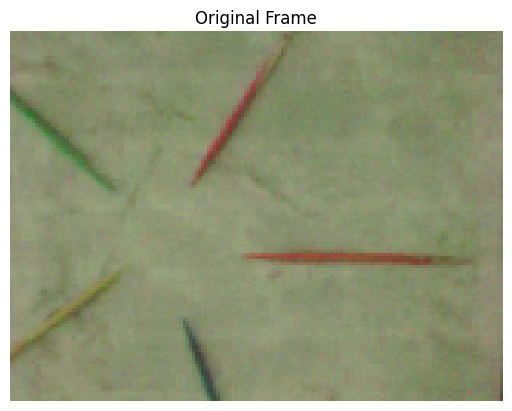

In [6]:
# Upload video, count frames, and show first frame


!pip install opencv-python-headless

import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# 1. Upload video

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)
# Read first frame (you can loop later)

ret, frame = cap.read()
cap.release()

if not ret:
    raise Exception("Could not read video")


# Convert BGR → RGB for display

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.title("Original Frame")
plt.axis("off")
plt.show()


Processing color: red
line 81 71 122 71
line 60 47 78 18


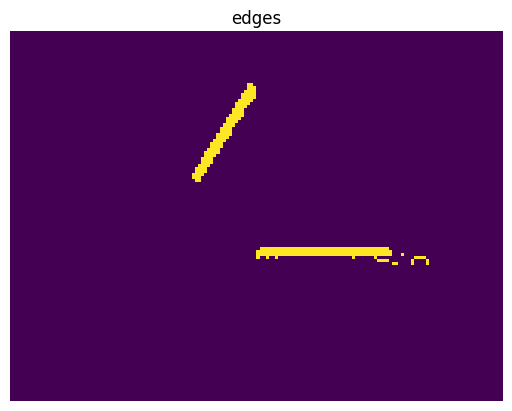

Processing color: orange
line 89 75 137 73


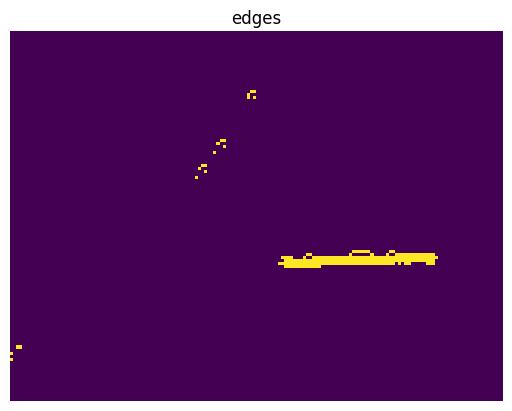

Processing color: yellow
no lines


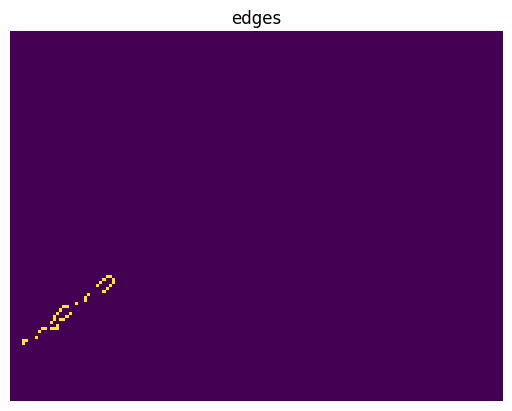

Processing color: green
line 3 19 33 50
line 1 26 30 51


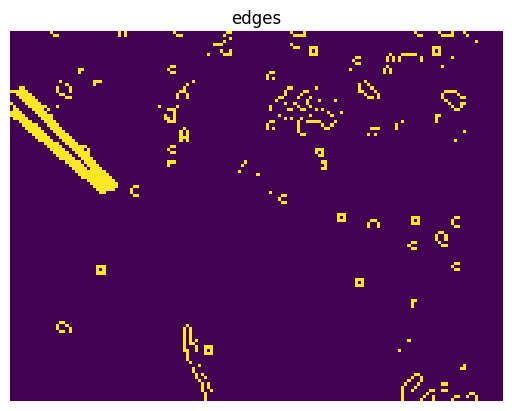

Processing color: blue
no lines


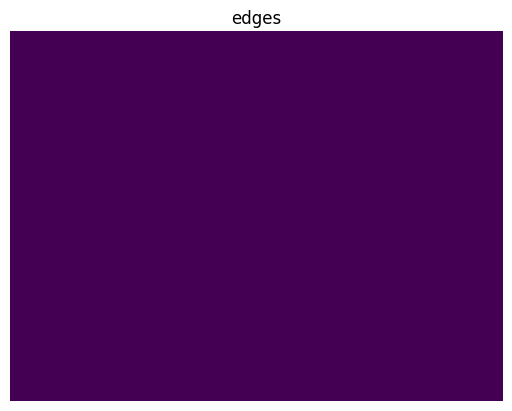

In [2]:

# 2. Convert to HSV (better for color segmentation)

hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# 3. Define color ranges (adjust depending on your chopsticks)

# Example: red, blue, green



color_ranges = {
"red": [
((0, 120, 70), (10, 255, 255)),
((170, 120, 70), (180, 255, 255))
],
"orange": [
((10, 120, 100), (25, 255, 255))
],
"yellow": [
((25, 120, 100), (35, 255, 255))
],
"green": [
((40, 70, 70), (80, 255, 255))
],
"blue": [
((100, 150, 0), (140, 255, 255))
]
}


# 4. Process each color

output = frame.copy()

for color, ranges in color_ranges.items():
    mask = None
    print(f"Processing color: {color}")


    # Combine multiple ranges (needed for red)
    for lower, upper in ranges:
        lower = np.array(lower)
        upper = np.array(upper)
        m = cv2.inRange(hsv, lower, upper)
        mask = m if mask is None else cv2.bitwise_or(mask, m)

    # 5. Edge detection
    edges = cv2.Canny(mask, 50, 150)

    # 6. Hough Transform
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180*1,
        threshold=20,
        minLineLength=10,
        maxLineGap=10
    )

    # 7. Draw lines
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            if color == "red":
                draw_color = (255, 0, 0)
            elif color == "green":
                draw_color = (0, 255, 0)
            else:
                draw_color = (0, 0, 255)
            print('line',x1, y1, x2, y2)
            cv2.line(edges, (x1, y1), (x2, y2), (255,255,255), 2)
    else:
        print('no lines')

    plt.imshow(edges)
    plt.title("edges")
    plt.axis("off")
    plt.show()




In [3]:
help(cv2.Canny)


Help on built-in function Canny:

Canny(...)
    Canny(image, threshold1, threshold2[, edges[, apertureSize[, L2gradient]]]) -> edges
    .   @brief Finds edges in an image using the Canny algorithm @cite Canny86 .
    .
    .   The function finds edges in the input image and marks them in the output map edges using the
    .   Canny algorithm. The smallest value between threshold1 and threshold2 is used for edge linking. The
    .   largest value is used to find initial segments of strong edges. See
    .   <https://en.wikipedia.org/wiki/Canny_edge_detector>
    .
    .   @param image 8-bit input image.
    .   @param edges output edge map; single channels 8-bit image, which has the same size as image .
    .   @param threshold1 first threshold for the hysteresis procedure.
    .   @param threshold2 second threshold for the hysteresis procedure.
    .   @param apertureSize aperture size for the Sobel operator.
    .   @param L2gradient a flag, indicating whether a more accurate \f$L_2